# Project 4 — Deep Learning Systems

## Problem Definition

This project uses deep learning with a Transformer model to detect rental listing risk patterns in text descriptions.

The dataset used is Toronto Kijiji Rental Data from Kaggle. It contains real rental advertisements with listing text and structured rental information.

The original annotation framework used three labels:

- **Safe**
- **Suspicious**
- **High Risk**

These labels reflect potential concerns such as vague wording, misleading claims, restrictive conditions, payment pressure, fraud-like requests, or other renter-risk signals.

Because the initial gold-standard dataset contained very few High Risk examples, the first modeling phase uses a binary classification setup:

- **Safe**
- **Risk**

## Dataset Source

Toronto Kijiji Rental Data (Kaggle)

https://www.kaggle.com/datasets/umeshkhatiwada/toronto-kijiji-rental-data

In [2]:
import pandas as pd

# Load dataset file
df = pd.read_csv("kijiji_rental_ads_4106.csv")

# Show number of rows and columns
print("Rows and Columns:", df.shape)

# Show all column names
print("\nColumns:")
print(df.columns)

# Show first 5 rows
df.head()

Rows and Columns: (4106, 23)

Columns:
Index(['Title', 'Price($)', 'Address', 'Date Posted', 'Building Type',
       'Bedrooms', 'Bathrooms', 'Utilities', 'Wi-Fi and More',
       'Parking Included', 'Agreement Type', 'Move-In Date', 'Pet Friendly',
       'Size (sqft)', 'Furnished', 'Air Conditioning',
       'Personal Outdoor Space', 'Smoking Permitted', 'Appliances',
       'Amenities', 'Description', 'Visit Counter', 'url'],
      dtype='object')


,Title,Price($),Address,Date Posted,Building Type,Bedrooms,Bathrooms,Utilities,Wi-Fi and More,Parking Included,...,Size (sqft),Furnished,Air Conditioning,Personal Outdoor Space,Smoking Permitted,Appliances,Amenities,Description,Visit Counter,url
0,6020 Bathurst Street - Valencia Towers Apartme...,3209.0,"6020 Bathurst Street, Toronto, ON, M2R 1Z8",2024-02-24 23:30:00,Apartment,2,1,NaN,Not Included,0,...,912,No,No,Not Included,No,Fridge / Freezer,Elevator in Building,Valencia Towers is a student- and family-frien...,NaN,https://www.kijiji.ca/v-apartments-condos/city...
1,RENOVATED BACHELOR SUITE AVAILABLE! Lakeview ...,2000.0,"22 Close Avenue, Toronto, ON, M6K 2V2",2024-03-14 00:09:49,Apartment,Bachelor/Studio,1,"Hydro_No,Heat_No,Water_Yes",Not Included,0,...,445,No,No,Balcony,No,"Laundry (In Building), Fridge / Freezer","Gym, Pool, Storage Space, Elevator in Building","Bachelors, 1 Bath, Recently Renovated Kitchen ...",NaN,https://www.kijiji.ca/v-apartments-condos/city...
2,50 Driftwood - Ruby Heights Apartment for Rent,2819.0,"50 Driftwood, Toronto, ON, M3N 2M6",2024-03-03 00:08:58,Apartment,2,1,NaN,Not Included,0,...,904,No,No,Not Included,No,Fridge / Freezer,"Storage Space, Elevator in Building","Ruby Heights, located in the North York distri...",NaN,https://www.kijiji.ca/v-apartments-condos/city...
3,1 Bed Apartment Rent today,2519.0,"100 Parkway Forest Drive, Toronto, ON, M2J 1L6",2024-03-06 00:35:06,Apartment,1,1,"Hydro_No,Heat_Yes,Water_Yes",Not Included,0,...,665,No,No,Yard,Yes,"Laundry (In Building), Fridge / Freezer","Gym, Pool, 24 Hour Security, Storage Space, El...","For a limited time, you can receive ONE MONTH ...",NaN,https://www.kijiji.ca/v-apartments-condos/city...
4,Brand New 2-bedroom Rental in North York! Yor...,2690.0,"1225 York Road, Toronto, ON, M3A 1Y4",2024-03-04 00:39:41,Apartment,2,1,NaN,Not Included,0,...,Not Available,No,Yes,Balcony,Yes,"Laundry (In Unit), Dishwasher, Fridge / Freezer","Gym, Bicycle Parking, Storage Space, Elevator ...",Realstar's ONE225 York Mills is North Yorks ne...,NaN,https://www.kijiji.ca/v-apartments-condos/city...


## Dataset Inspection Notes

The dataset contains 4,106 rows and 23 columns, which is enough for a deep learning text classification project.

Important columns in this dataset include `Title`, `Price($)`, `Bedrooms`, `Bathrooms`, `Address`, and `Description`.

The most important text column for this project is `Description`, because it contains the main rental listing language that can be used for Transformer-based NLP.

Some columns may need cleaning because they contain missing values, mixed formats, or text that is not useful for the classification task.

In [4]:
# Check data types
print("Data types:")
print(df.dtypes)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check the main text column
print("\nExample descriptions:")
for i, text in enumerate(df["Description"].dropna().head(3), 1):
    print(f"\nExample {i}:")
    print(text[:500])  # show first 500 characters only

Data types:
Title                      object
Price($)                  float64
Address                    object
Date Posted                object
Building Type              object
Bedrooms                   object
Bathrooms                  object
Utilities                  object
Wi-Fi and More             object
Parking Included           object
Agreement Type             object
Move-In Date               object
Pet Friendly               object
Size (sqft)                object
Furnished                  object
Air Conditioning           object
Personal Outdoor Space     object
Smoking Permitted          object
Appliances                 object
Amenities                  object
Description                object
Visit Counter              object
url                        object
dtype: object

Missing values:
Title                        7
Price($)                   256
Address                     12
Date Posted                608
Building Type             1025
Bedrooms            

## Dataset Inspection Notes

- Most columns in the dataset are stored in text format, while the rental price column is numeric.

- Several columns contain missing values, especially optional property features such as amenities, utilities, and move-in date.

- The most important column for this project is `Description`, because it contains the main rental listing text that will be used for Transformer-based classification.

- The example descriptions show real rental language, promotional wording, contact requests, and housing details. This makes the dataset suitable for natural language processing.

- Before modeling, rows with missing descriptions will be removed and text data will be cleaned.

## Data Cleaning and Text Preparation

The dataset was cleaned before deep learning modeling.

The main text column used for this project is `Description`.

Rows with missing descriptions were removed, duplicate text entries were removed, and extra spaces were cleaned from the text.

In [5]:
# Make a clean copy of the dataset
df_clean = df.copy()

# Keep only rows that have description text
df_clean = df_clean.dropna(subset=["Description"])

# Remove duplicate descriptions
df_clean = df_clean.drop_duplicates(subset=["Description"])

# Convert description to string
df_clean["Description"] = df_clean["Description"].astype(str)

# Remove extra spaces
df_clean["Description"] = df_clean["Description"].str.replace(r"\s+", " ", regex=True).str.strip()

# Show updated shape
print("Rows and Columns after cleaning:", df_clean.shape)

# Show first few cleaned rows
df_clean[["Title", "Description"]].head()

Rows and Columns after cleaning: (2796, 23)


,Title,Description
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...
1,RENOVATED BACHELOR SUITE AVAILABLE! Lakeview ...,"Bachelors, 1 Bath, Recently Renovated Kitchen ..."
2,50 Driftwood - Ruby Heights Apartment for Rent,"Ruby Heights, located in the North York distri..."
3,1 Bed Apartment Rent today,"For a limited time, you can receive ONE MONTH ..."
4,Brand New 2-bedroom Rental in North York! Yor...,Realstar's ONE225 York Mills is North Yorks ne...


## Public Guidance Used for Annotation Framework

To support research-grade labeling, publicly available Canadian rental safety and fraud guidance was reviewed from three sources:

- Competition Bureau Canada
- RCMP Canada
- University of Toronto fraud prevention guidance

The page text was collected using `trafilatura` and reviewed to identify common renter-risk signals, such as deposit requests before viewing, money transfer requests, personal information requests, misleading urgency language, and lack of formal lease processes.

These sources were used as reference material to guide manual annotation of rental listing descriptions rather than to automatically generate labels.

In [13]:
# Install required libraries
!pip install trafilatura

In [14]:
# If needed, install once:
# !pip install trafilatura

import trafilatura

# Public Canadian guidance sources
urls = [
    "https://www.canada.ca/en/competition-bureau/news/2018/08/rental-scam-no-room-for-error.html",
    "https://rcmp.ca/en/bc/safety-tips/frauds-and-scams/rental-scams",
    "https://www.communitysafety.utoronto.ca/fraud-prevention/fraud-prevention-tips/fraud-prevention-tip-landlord-or-rental-scams/"
]

# Collect text
all_text = ""

for url in urls:
    downloaded = trafilatura.fetch_url(url)
    extracted_text = trafilatura.extract(downloaded)

    if extracted_text:
        all_text += extracted_text + "\n\n"

# Show preview of reference material
print(all_text[:3000])

Rental scam: no room for error
News release
August 16, 2018 – OTTAWA, ON – Competition Bureau
It’s peak moving season. Students are leaving the nest; parents are helping them find the right place. Beware: if a rental listing looks too good to be true, it probably is. School might not have started yet, but do your homework and learn to recognize rental scams.
In a typical rental scam, fraudsters will entice you with a very attractive listing: sought after area, great amenities and low price. Ads will be posted on popular sites like Kijiji or Facebook. Scammers may use photos from an old listing, from a house that’s up for sale, or from short-term rental sites like Airbnb, to make it look authentic. They pose as the landlord and may claim to be abroad and unable to meet in person to show you inside the place.
After a few emails or text messages, they will start asking for money. First, they’ll try to get a security deposit, then, they’ll ask for the first month’s rent, and then another m

## Why the Public Guidance Text Was Collected

The extracted public guidance text was used to support the annotation framework for manual labeling.

It may also be used later for semantic comparison or error analysis, since rental descriptions can be compared against public scam and renter-risk guidance.

## Final Annotation Framework

This project uses a broader rental listing risk detection framework rather than scam-only detection.

Each listing is manually labeled into one of three classes:

- **Safe**: Normal rental listing language with no clear concerning signals.
- **Suspicious**: Low-trust, vague, restrictive, misleading, or unusual wording that may require caution.
- **High Risk**: Strong concerning signals such as payment pressure, fraud-like requests, exploitative restrictions, or serious fairness concerns.

This broader framework better reflects real rental risks faced by renters in practice.

In [15]:
# Keep only rows with usable descriptions
annot_df = df_clean[["Title", "Description"]].copy()

# Reset index
annot_df = annot_df.reset_index(drop=True)

# Take first 30 rows for manual annotation starter set
sample_df = annot_df.head(30).copy()

# Add empty label column
sample_df["Risk_Label"] = ""

# Show rows for annotation
sample_df[["Title", "Description", "Risk_Label"]]

,Title,Description,Risk_Label
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,
1,RENOVATED BACHELOR SUITE AVAILABLE! Lakeview ...,"Bachelors, 1 Bath, Recently Renovated Kitchen ...",
2,50 Driftwood - Ruby Heights Apartment for Rent,"Ruby Heights, located in the North York distri...",
3,1 Bed Apartment Rent today,"For a limited time, you can receive ONE MONTH ...",
4,Brand New 2-bedroom Rental in North York! Yor...,Realstar's ONE225 York Mills is North Yorks ne...,
5,Furnished room available (Eglinton West Statio...,Clean 3 bedroom furnished apartment. Room avai...,
6,Collegiate Court - 1 Bedroom Apartment for Rent,"A clean, quiet and well-maintained rental buil...",
7,Chatsworth Apartments - 1 Bdrm available at 29...,1 Month Free Rent,
8,Basement for rent in Scarborough,2 bedrooms 1 washroom full renovate basement a...,
9,One Bedroom condo available,Discover the epitome of modern living in our o...,


## Manual Annotation Process

The first sample of listings was manually reviewed using Canadian public rental guidance and broader renter-risk criteria.

Labels used:

- **Safe** = normal listing language with no clear concern  
- **Suspicious** = vague wording, restrictive conditions, misleading claims, unusual requests, or low-trust signals  
- **High Risk** = strong concerning signals such as fraud-like requests, payment pressure, exploitative restrictions, or serious renter-risk indicators

In [16]:
# Manually assign first 10 labels
sample_df.loc[0, "Risk_Label"] = "Safe"
sample_df.loc[1, "Risk_Label"] = "Safe"
sample_df.loc[2, "Risk_Label"] = "Safe"
sample_df.loc[3, "Risk_Label"] = "Suspicious"
sample_df.loc[4, "Risk_Label"] = "Safe"
sample_df.loc[5, "Risk_Label"] = "Safe"
sample_df.loc[6, "Risk_Label"] = "Safe"
sample_df.loc[7, "Risk_Label"] = "Suspicious"
sample_df.loc[8, "Risk_Label"] = "Safe"
sample_df.loc[9, "Risk_Label"] = "Safe"

# Show first 10 labeled rows
sample_df.head(10)

,Title,Description,Risk_Label
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,Safe
1,RENOVATED BACHELOR SUITE AVAILABLE! Lakeview ...,"Bachelors, 1 Bath, Recently Renovated Kitchen ...",Safe
2,50 Driftwood - Ruby Heights Apartment for Rent,"Ruby Heights, located in the North York distri...",Safe
3,1 Bed Apartment Rent today,"For a limited time, you can receive ONE MONTH ...",Suspicious
4,Brand New 2-bedroom Rental in North York! Yor...,Realstar's ONE225 York Mills is North Yorks ne...,Safe
5,Furnished room available (Eglinton West Statio...,Clean 3 bedroom furnished apartment. Room avai...,Safe
6,Collegiate Court - 1 Bedroom Apartment for Rent,"A clean, quiet and well-maintained rental buil...",Safe
7,Chatsworth Apartments - 1 Bdrm available at 29...,1 Month Free Rent,Suspicious
8,Basement for rent in Scarborough,2 bedrooms 1 washroom full renovate basement a...,Safe
9,One Bedroom condo available,Discover the epitome of modern living in our o...,Safe


In [17]:
# Manually assign rows 10 to 19
sample_df.loc[10, "Risk_Label"] = "Safe"
sample_df.loc[11, "Risk_Label"] = "Suspicious"
sample_df.loc[12, "Risk_Label"] = "Suspicious"
sample_df.loc[13, "Risk_Label"] = "Safe"
sample_df.loc[14, "Risk_Label"] = "Safe"
sample_df.loc[15, "Risk_Label"] = "Safe"
sample_df.loc[16, "Risk_Label"] = "Suspicious"
sample_df.loc[17, "Risk_Label"] = "Suspicious"
sample_df.loc[18, "Risk_Label"] = "Safe"
sample_df.loc[19, "Risk_Label"] = "Safe"

# Show rows 10 to 19
sample_df.loc[10:19]

,Title,Description,Risk_Label
10,Large renovated 1 Bedroom with balcony at Bath...,Large renovated 1 bedroom with balcony and har...,Safe
11,Queen and woodbine beaches,2 bed 2 nd floor apartment for rent Available ...,Suspicious
12,3 Bedroom Apartment for Rent - 3434 Eglinton A...,Utilities Included,Suspicious
13,"2 Bed, 1 Bath Basement Apartment for Rent in W...",Thanks for reading. Up for rent is a 2 bedroom...,Safe
14,1 Bed 1 Bath - Apartment,"Incredible loft-style living in a remarkable, ...",Safe
15,One bedroom apartment for rent,Pickering one bedroom apartment for rent. Sepa...,Safe
16,105 West Lodge - 1 Bedroom Apartment in the He...,Building Overivew,Suspicious
17,"HUGE 50' x 50' yard. ALL main house. Prime, sa...","**FREE WIFI, PARKING and ALL CURTAINS included...",Suspicious
18,Newly Renovated 1 Bedroom Basement for rent,Brand new legal basement apartment with separa...,Safe
19,Subletting a Cozy and Stylish Dorm Room for 2 ...,Dorm room available for 2 months from June 1st...,Safe


In [18]:
# Manually assign rows 20 to 29
sample_df.loc[20, "Risk_Label"] = "Suspicious"
sample_df.loc[21, "Risk_Label"] = "Safe"
sample_df.loc[22, "Risk_Label"] = "Safe"
sample_df.loc[23, "Risk_Label"] = "Safe"
sample_df.loc[24, "Risk_Label"] = "Suspicious"
sample_df.loc[25, "Risk_Label"] = "Safe"
sample_df.loc[26, "Risk_Label"] = "Safe"
sample_df.loc[27, "Risk_Label"] = "Safe"
sample_df.loc[28, "Risk_Label"] = "High Risk"
sample_df.loc[29, "Risk_Label"] = "Safe"

# Show rows 20 to 29
sample_df.loc[20:29]

,Title,Description,Risk_Label
20,"New Two-Bedroom Townhome Rentals- Move In Now,...","Move In Now, Don't Pay Until May 1stOpen House...",Suspicious
21,Furnished 2 bedrooms Basement Apartment - Rich...,Looking for a comfortable and well-equipped li...,Safe
22,Room for rent,Bechelorstudio apartment Markham/ Eglinton (Sc...,Safe
23,Spacious Apartment in South Parkdale-All utili...,Best All Inclusive Lease In South Parkdale. Ne...,Safe
24,Golden Mile 1 Bedroom Apartment for Rent - 32 ...,Current Promotions,Suspicious
25,"Open Concept Loft, 18' ceiling, Live/Work Studio","Perfect for Yoga Studio, Creative Agency, Phot...",Safe
26,Large 1 Bed Room Basement Apartment Prime Loca...,"Prime location Queen St. East, downtown Toront...",Safe
27,2 bedroom apartment for rent sublease,Near weston and finchUtilities and car parking...,Safe
28,FINCH&BATHURST-MALE ONLY-MONTH TO MONTH RENTAL...,"Welcome,",High Risk
29,"2 bdrm +den - Fifty on the Park,","2 bdrm +den , 1 bath east view3 black applianc...",Safe


In [19]:
# Check label counts
sample_df["Risk_Label"].value_counts()

Risk_Label
Safe          21
Suspicious     8
High Risk      1
Name: count, dtype: int64

In [20]:
# Targeted sampling using separate risk groups

fraud_terms = [
    "deposit",
    "send money",
    "e-transfer",
    "wire transfer",
    "cash only",
    "urgent",
    "must rent",
    "pay now",
    "credit card",
    "first month"
]

restriction_terms = [
    "male only",
    "female only",
    "students only",
    "no students",
    "no newcomers",
    "couples only"
]

# Fraud / payment candidates
fraud_mask = df_clean["Description"].str.lower().str.contains(
    "|".join(fraud_terms), na=False
)

fraud_candidates = df_clean.loc[
    fraud_mask, ["Title", "Description"]
].copy()

# Restriction / fairness candidates
restriction_mask = df_clean["Description"].str.lower().str.contains(
    "|".join(restriction_terms), na=False
)

restriction_candidates = df_clean.loc[
    restriction_mask, ["Title", "Description"]
].copy()

print("Fraud candidates:", len(fraud_candidates))
print("Restriction candidates:", len(restriction_candidates))

print("\nFraud examples:")
display(fraud_candidates.head(15))

print("\nRestriction examples:")
display(restriction_candidates.head(15))

Fraud candidates: 121
Restriction candidates: 33

Fraud examples:


,Title,Description
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...
61,Oriole Apartments - Bachelor available at 1 Or...,No Last Month's Rent Deposit
141,831 Kennedy Road - 831 Kennedy Apartment for Rent,Situated in a family-oriented area of Scarboro...
150,"Looking for a Female Roommate in a 3 bed, 2 Wa...","Hello everyone, I am looking for a third roomm..."
164,Bayview and Finch Basement Apartment,- 2 Bright Large Bedrooms (13' x 13' and 13' x...
184,797 Jane Street - Hannah Woods Apartment for Rent,Welcome to The Woods at 797 Jane Street. This ...
207,6030 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...
215,Private room for rent,Room in a three bedroom apartment in prime loc...
227,Newly Renovated 2 brm Apt with balcony-=Cosbur...,Available April 1- Fully renovated 2 brm Apt w...
243,Room for Rent,Looking for 2 long term girls flatmate to rent...



Restriction examples:


,Title,Description
13,Queen and woodbine beaches,2 bed 2 nd floor apartment for rent Available ...
150,"Looking for a Female Roommate in a 3 bed, 2 Wa...","Hello everyone, I am looking for a third roomm..."
170,2 Bed rooms apartment for rent,2 Bedrooms apartment for rent Female Students ...
1161,University of Toronto Summer Sublet - $1500 Pe...,"FEMALE ONLY. May through August, 2024. One (lo..."
1211,Living room space for rent,Living space for a single person in a 2 bedroo...
1236,Downtown Toronto private bedroom with private ...,"Female only Two room available First room , Se..."
1281,One private bedroom in a two bed and 1 bath condo,A very nice furnished one bedroom in a two-bed...
1342,Room for rent in West Hill Community,"Bright room fully furnished (bed, closet, desk..."
1559,2 bedroom basement for rent,Available 2 bedroom in a basement apartment fo...
1816,Room for rent,"Hello! everyone, A four-bedroom basement apart..."


## Targeted Sampling for Underrepresented Risk Classes

Because the initial random sample contained few High Risk examples, targeted sampling was used to identify listings more likely to contain underrepresented renter-risk signals.

Two targeted groups were reviewed:

- **Fraud / Payment Risk** (deposit requests, money transfer requests, payment pressure)
- **Restriction / Fairness Risk** (restrictive renter preferences or access conditions)

This process helps improve class balance before Transformer training.

## Manual Review of Targeted Risk Candidates

Listings identified through targeted sampling were manually reviewed and labeled.

This step increases the number of Suspicious and High Risk examples while maintaining human-reviewed labels.

In [21]:
# Create review sample from targeted candidates
review_df = pd.concat(
    [
        fraud_candidates.head(20),
        restriction_candidates.head(10)
    ],
    ignore_index=True
).drop_duplicates()

# Reset index
review_df = review_df.reset_index(drop=True)

# Add empty labels
review_df["Risk_Label"] = ""

# Show rows for review
review_df

,Title,Description,Risk_Label
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,
1,Oriole Apartments - Bachelor available at 1 Or...,No Last Month's Rent Deposit,
2,831 Kennedy Road - 831 Kennedy Apartment for Rent,Situated in a family-oriented area of Scarboro...,
3,"Looking for a Female Roommate in a 3 bed, 2 Wa...","Hello everyone, I am looking for a third roomm...",
4,Bayview and Finch Basement Apartment,- 2 Bright Large Bedrooms (13' x 13' and 13' x...,
5,797 Jane Street - Hannah Woods Apartment for Rent,Welcome to The Woods at 797 Jane Street. This ...,
6,6030 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,
7,Private room for rent,Room in a three bedroom apartment in prime loc...,
8,Newly Renovated 2 brm Apt with balcony-=Cosbur...,Available April 1- Fully renovated 2 brm Apt w...,
9,Room for Rent,Looking for 2 long term girls flatmate to rent...,


## Manual Labeling of Targeted Candidate Listings

Targeted candidate listings were manually reviewed to enrich the dataset with underrepresented Suspicious and High Risk examples.

In [22]:
# Label rows 0 to 14
review_df.loc[0, "Risk_Label"] = "Safe"
review_df.loc[1, "Risk_Label"] = "Safe"
review_df.loc[2, "Risk_Label"] = "Safe"
review_df.loc[3, "Risk_Label"] = "Suspicious"
review_df.loc[4, "Risk_Label"] = "Safe"
review_df.loc[5, "Risk_Label"] = "Safe"
review_df.loc[6, "Risk_Label"] = "Safe"
review_df.loc[7, "Risk_Label"] = "Safe"
review_df.loc[8, "Risk_Label"] = "Safe"
review_df.loc[9, "Risk_Label"] = "Suspicious"
review_df.loc[10, "Risk_Label"] = "Safe"
review_df.loc[11, "Risk_Label"] = "Suspicious"
review_df.loc[12, "Risk_Label"] = "Suspicious"
review_df.loc[13, "Risk_Label"] = "Safe"
review_df.loc[14, "Risk_Label"] = "Safe"

# Show first 15 labeled rows
review_df.head(15)

,Title,Description,Risk_Label
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,Safe
1,Oriole Apartments - Bachelor available at 1 Or...,No Last Month's Rent Deposit,Safe
2,831 Kennedy Road - 831 Kennedy Apartment for Rent,Situated in a family-oriented area of Scarboro...,Safe
3,"Looking for a Female Roommate in a 3 bed, 2 Wa...","Hello everyone, I am looking for a third roomm...",Suspicious
4,Bayview and Finch Basement Apartment,- 2 Bright Large Bedrooms (13' x 13' and 13' x...,Safe
5,797 Jane Street - Hannah Woods Apartment for Rent,Welcome to The Woods at 797 Jane Street. This ...,Safe
6,6030 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,Safe
7,Private room for rent,Room in a three bedroom apartment in prime loc...,Safe
8,Newly Renovated 2 brm Apt with balcony-=Cosbur...,Available April 1- Fully renovated 2 brm Apt w...,Safe
9,Room for Rent,Looking for 2 long term girls flatmate to rent...,Suspicious


In [23]:
# Label rows 15 to 29
review_df.loc[15, "Risk_Label"] = "Suspicious"
review_df.loc[16, "Risk_Label"] = "Safe"
review_df.loc[17, "Risk_Label"] = "Suspicious"
review_df.loc[18, "Risk_Label"] = "Suspicious"
review_df.loc[19, "Risk_Label"] = "Safe"
review_df.loc[20, "Risk_Label"] = "Suspicious"
review_df.loc[21, "Risk_Label"] = "Suspicious"
review_df.loc[22, "Risk_Label"] = "Suspicious"
review_df.loc[23, "Risk_Label"] = "Safe"
review_df.loc[24, "Risk_Label"] = "Suspicious"
review_df.loc[25, "Risk_Label"] = "Safe"
review_df.loc[26, "Risk_Label"] = "Safe"
review_df.loc[27, "Risk_Label"] = "Safe"
review_df.loc[28, "Risk_Label"] = "Safe"
review_df.loc[29, "Risk_Label"] = "Safe"

# Show rows 15 to 29
review_df.loc[15:29]

,Title,Description,Risk_Label
15,Room for rent in North York. Shared for female...,We are looking for a female student to share a...,Suspicious
16,Studio apartment (private)for rent Basement Ma...,Studio apartment (private)for rent Basement Ma...,Safe
17,Newly Built 2Bedroom Stack Town at high demand...,"Moving in by May 1! This stunning two-bedroom,...",Suspicious
18,APR 1 | FURNISHED | TORONTO | WIFI & UTIL INCL,Available April 1 Text Kat 647-521-9158 with y...,Suspicious
19,1 Bed + Den with 2 full bath apartment for rent,Stunning 2-Bedroom Condo! Welcome to your new ...,Safe
20,Queen and woodbine beaches,2 bed 2 nd floor apartment for rent Available ...,Suspicious
21,2 Bed rooms apartment for rent,2 Bedrooms apartment for rent Female Students ...,Suspicious
22,University of Toronto Summer Sublet - $1500 Pe...,"FEMALE ONLY. May through August, 2024. One (lo...",Suspicious
23,Living room space for rent,Living space for a single person in a 2 bedroo...,Safe
24,Downtown Toronto private bedroom with private ...,"Female only Two room available First room , Se...",Suspicious


## Combine Labeled Annotation Sets

The manually labeled random sample and the manually labeled targeted sample were combined into one annotation dataset.

This combined dataset will be used as the first gold-standard labeled set for Transformer training and evaluation.

In [24]:
# Combine the two labeled datasets
gold_df = pd.concat([sample_df, review_df], ignore_index=True)

# Remove duplicate rows based on Title and Description
gold_df = gold_df.drop_duplicates(subset=["Title", "Description"]).reset_index(drop=True)

# Keep only labeled rows
gold_df = gold_df[gold_df["Risk_Label"] != ""].copy()

# Show shape and label counts
print("Gold dataset shape:", gold_df.shape)
print("\nLabel counts:")
print(gold_df["Risk_Label"].value_counts())

# Preview combined dataset
gold_df.head()

Gold dataset shape: (58, 3)

Label counts:
Risk_Label
Safe          39
Suspicious    18
High Risk      1
Name: count, dtype: int64


,Title,Description,Risk_Label
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,Safe
1,RENOVATED BACHELOR SUITE AVAILABLE! Lakeview ...,"Bachelors, 1 Bath, Recently Renovated Kitchen ...",Safe
2,50 Driftwood - Ruby Heights Apartment for Rent,"Ruby Heights, located in the North York distri...",Safe
3,1 Bed Apartment Rent today,"For a limited time, you can receive ONE MONTH ...",Suspicious
4,Brand New 2-bedroom Rental in North York! Yor...,Realstar's ONE225 York Mills is North Yorks ne...,Safe


## Binary Risk Classification Setup

Because the initial labeled dataset contained very few High Risk examples, Suspicious and High Risk labels were combined into a single Risk class for the first modeling phase.

This produced a more stable binary classification task:

- Safe
- Risk

In [26]:
# Create binary target label
gold_df["Binary_Label"] = gold_df["Risk_Label"].replace({
    "Safe": "Safe",
    "Suspicious": "Risk",
    "High Risk": "Risk"
})

# Show counts
print(gold_df["Binary_Label"].value_counts())

# Preview
gold_df.head()

Binary_Label
Safe    39
Risk    19
Name: count, dtype: int64


,Title,Description,Risk_Label,Binary_Label
0,6020 Bathurst Street - Valencia Towers Apartme...,Valencia Towers is a student- and family-frien...,Safe,Safe
1,RENOVATED BACHELOR SUITE AVAILABLE! Lakeview ...,"Bachelors, 1 Bath, Recently Renovated Kitchen ...",Safe,Safe
2,50 Driftwood - Ruby Heights Apartment for Rent,"Ruby Heights, located in the North York distri...",Safe,Safe
3,1 Bed Apartment Rent today,"For a limited time, you can receive ONE MONTH ...",Suspicious,Risk
4,Brand New 2-bedroom Rental in North York! Yor...,Realstar's ONE225 York Mills is North Yorks ne...,Safe,Safe


## Prepare Final Modeling Dataset

Before Transformer training, the combined gold-standard dataset was checked one more time.

Rows with missing text or missing labels were removed, and the final binary classification dataset was prepared for train-test splitting.

In [27]:
# Remove rows with missing description or missing binary label
gold_df = gold_df.dropna(subset=["Description", "Binary_Label"]).copy()

# Keep only needed columns for modeling
model_df = gold_df[["Description", "Binary_Label"]].copy()

# Reset index
model_df = model_df.reset_index(drop=True)

# Show final shape and class balance
print("Final modeling dataset shape:", model_df.shape)
print("\nBinary label counts:")
print(model_df["Binary_Label"].value_counts())

# Preview
model_df.head()

Final modeling dataset shape: (57, 2)

Binary label counts:
Binary_Label
Safe    38
Risk    19
Name: count, dtype: int64


,Description,Binary_Label
0,Valencia Towers is a student- and family-frien...,Safe
1,"Bachelors, 1 Bath, Recently Renovated Kitchen ...",Safe
2,"Ruby Heights, located in the North York distri...",Safe
3,"For a limited time, you can receive ONE MONTH ...",Risk
4,Realstar's ONE225 York Mills is North Yorks ne...,Safe


## Train-Test Split for Transformer Modeling

The final modeling dataset was prepared for binary text classification.

The target labels were converted into numeric format, and the data was split into training and testing sets.

A stratified split was used so that both classes remain represented in each set.

In [28]:
from sklearn.model_selection import train_test_split

# Convert text labels to numeric labels
label_map = {
    "Safe": 0,
    "Risk": 1
}

model_df["label"] = model_df["Binary_Label"].map(label_map)

# Define input text and target
X = model_df["Description"]
y = model_df["label"]

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Show split sizes
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label counts:")
print(y_train.value_counts())

print("\nTesting label counts:")
print(y_test.value_counts())

Training samples: 45
Testing samples: 12

Training label counts:
label
0    30
1    15
Name: count, dtype: int64

Testing label counts:
label
0    8
1    4
Name: count, dtype: int64


## Tokenization and PyTorch Dataset Preparation

The rental descriptions were tokenized using the DistilBERT tokenizer.

A custom PyTorch dataset class was created so the text and labels could be loaded into the Transformer model in a format suitable for training and evaluation.

In [29]:
# If needed, install once:
# !pip install transformers torch

import torch
from torch.utils.data import Dataset
from transformers import DistilBertTokenizer

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Create custom dataset class
class RentalRiskDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Create train and test datasets
train_dataset = RentalRiskDataset(X_train, y_train, tokenizer)
test_dataset = RentalRiskDataset(X_test, y_test, tokenizer)

# Check one sample
sample_item = train_dataset[0]

print("Sample keys:", sample_item.keys())
print("Input shape:", sample_item["input_ids"].shape)
print("Attention mask shape:", sample_item["attention_mask"].shape)
print("Label:", sample_item["label"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample keys: dict_keys(['input_ids', 'attention_mask', 'label'])
Input shape: torch.Size([256])
Attention mask shape: torch.Size([256])
Label: tensor(1)


## Baseline Transformer Model

The baseline model for this project uses DistilBERT for binary text classification.

DistilBERT was selected because it is a compact Transformer model that performs well on NLP tasks while requiring less computation than full BERT.

A classification head is added on top of the Transformer to predict one of two classes:

- Safe
- Risk

In [30]:
from torch.utils.data import DataLoader
from transformers import DistilBertForSequenceClassification

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4)

# Load baseline DistilBERT model for binary classification
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# Check model
print(model)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Baseline Model Training

The DistilBERT baseline model was fine-tuned on the rental listing dataset.

Cross-entropy loss was used automatically through the Hugging Face model output, and the AdamW optimizer was used for parameter updates.

Training progress was monitored across epochs.

In [32]:
import torch
from torch.optim import AdamW

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move model to device
model = model.to(device)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training settings
epochs = 3

# Store losses
train_losses = []

# Training loop
model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Using device: cpu
Epoch 1/3 - Loss: 0.6521
Epoch 2/3 - Loss: 0.5877
Epoch 3/3 - Loss: 0.5466


## Baseline Model Evaluation

After training, the baseline DistilBERT model was evaluated on the test set.

Accuracy, a classification report, and a confusion matrix were used to assess baseline performance.

Baseline Test Accuracy: 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

        Safe       0.67      1.00      0.80         8
        Risk       0.00      0.00      0.00         4

    accuracy                           0.67        12
   macro avg       0.33      0.50      0.40        12
weighted avg       0.44      0.67      0.53        12



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


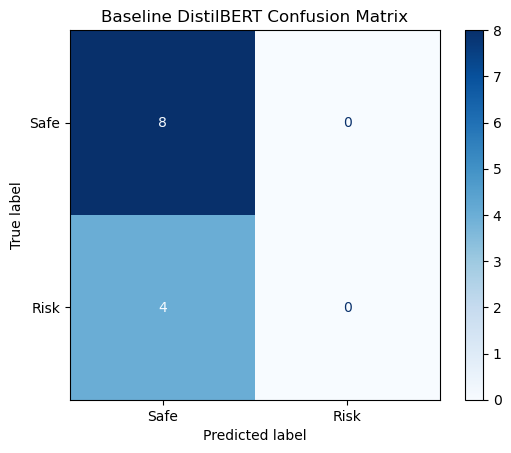

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Evaluation mode
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Accuracy
acc = accuracy_score(true_labels, predictions)
print("Baseline Test Accuracy:", acc)

# Classification report
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=["Safe", "Risk"]))

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Risk"])
disp.plot(cmap="Blues")
plt.title("Baseline DistilBERT Confusion Matrix")
plt.show()